Saving fruits.jpg to fruits.jpg
Gambar yang diupload: fruits.jpg


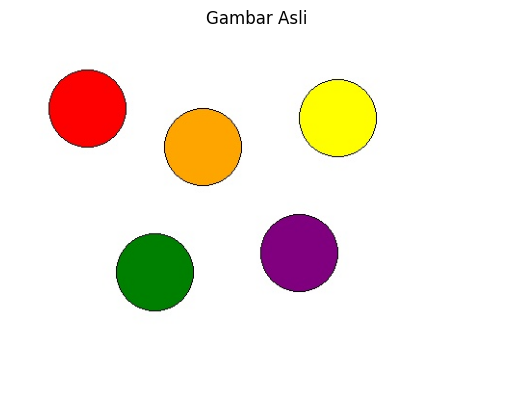

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload gambar apel (objek merah)
uploaded = files.upload()

# Baca gambar
for fn in uploaded.keys():
    image_path = fn
    print('Gambar yang diupload:', image_path)

# Baca dan ubah ke RGB
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")
plt.show()


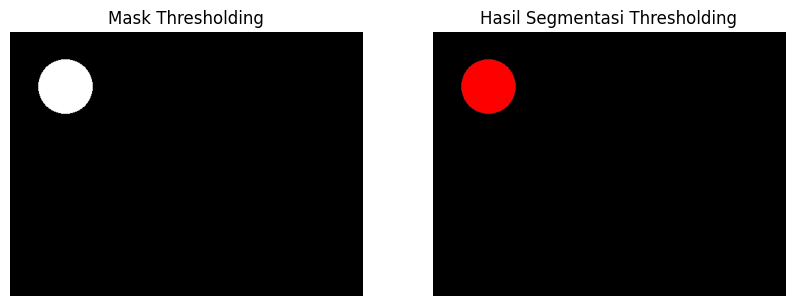

In [2]:
# Konversi ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Rentang warna merah (HSV)
lower_red1 = np.array([0, 100, 100])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([160, 100, 100])
upper_red2 = np.array([180, 255, 255])

# Mask warna merah
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask = mask1 + mask2

# Terapkan masking
result = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(mask, cmap='gray')
plt.title("Mask Thresholding")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(result)
plt.title("Hasil Segmentasi Thresholding")
plt.axis("off")
plt.show()


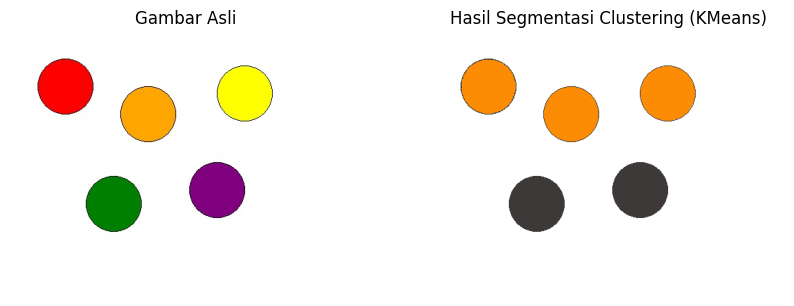

In [3]:
Z = img_rgb.reshape((-1,3))
Z = np.float32(Z)

# Tentukan jumlah cluster (misal 3: objek, background, shadow)
K = 3
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img_rgb.shape))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(res2)
plt.title("Hasil Segmentasi Clustering (KMeans)")
plt.axis("off")
plt.show()

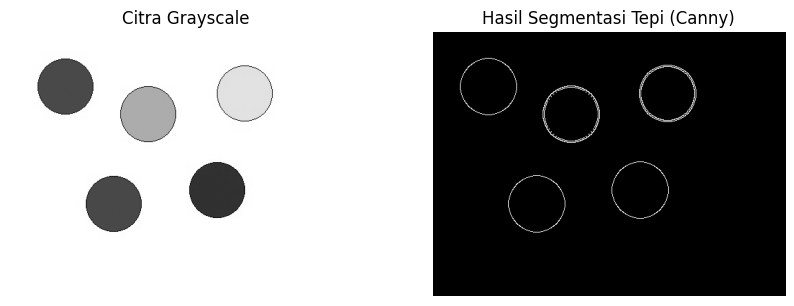

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Citra Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Hasil Segmentasi Tepi (Canny)")
plt.axis("off")
plt.show()

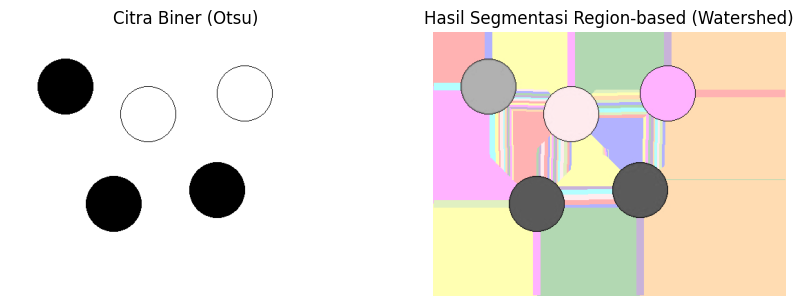

In [5]:
from scipy import ndimage as ndi
from skimage import color, feature, segmentation, filters, measure, morphology

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Filter biner
thresh = filters.threshold_otsu(gray)
bw = gray > thresh

# Label area
distance = ndi.distance_transform_edt(bw)
coords = feature.peak_local_max(distance, footprint=np.ones((3, 3)), labels=bw)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True

markers, _ = ndi.label(mask)
labels = segmentation.watershed(-distance, markers, mask=bw)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(bw, cmap='gray')
plt.title("Citra Biner (Otsu)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(color.label2rgb(labels, image=img_rgb))
plt.title("Hasil Segmentasi Region-based (Watershed)")
plt.axis("off")
plt.show()

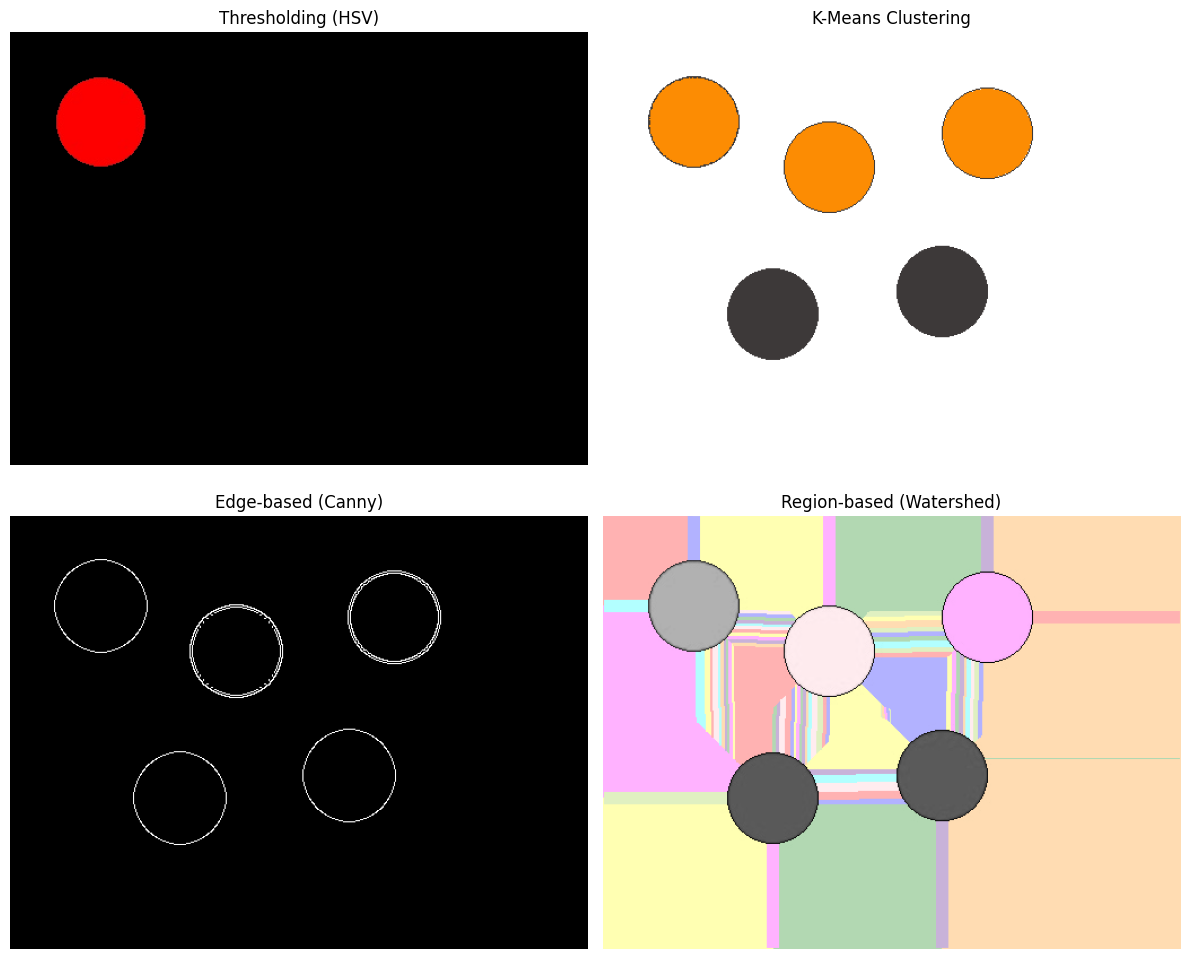

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()

axes[0].imshow(result)
axes[0].set_title("Thresholding (HSV)")

axes[1].imshow(res2)
axes[1].set_title("K-Means Clustering")

axes[2].imshow(edges, cmap='gray')
axes[2].set_title("Edge-based (Canny)")

axes[3].imshow(color.label2rgb(labels, image=img_rgb))
axes[3].set_title("Region-based (Watershed)")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()